In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("sleep.csv")
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
data = data.drop(columns = ["Person ID"])

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Blood Pressure           374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 35.2+ KB


In [5]:
data = data.fillna({"Sleep Disorder": "Нет"})
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Blood Pressure           374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 35.2+ KB


In [6]:
data.Gender = data.Gender.map({"Female": 1,
                "Male": 0})

In [7]:
data["BMI Category"].value_counts()

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

In [8]:
data["BMI Category"] = data["BMI Category"].replace({"Normal Weight": "Normal"})

In [9]:
data["Blood Pressure Sist"] = data["Blood Pressure"].apply(lambda x: int(x.split("/")[0]))
data["Blood Pressure Diast"] = data["Blood Pressure"].apply(lambda x: int(x.split("/")[1]))
data = data.drop(columns = "Blood Pressure")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    int64  
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Blood Pressure Sist      374 non-null    int64  
 12  Blood Pressure Diast     374 non-null    int64  
dtypes: float64(1), int64(9), object(3)
memory usage: 38.1+ KB


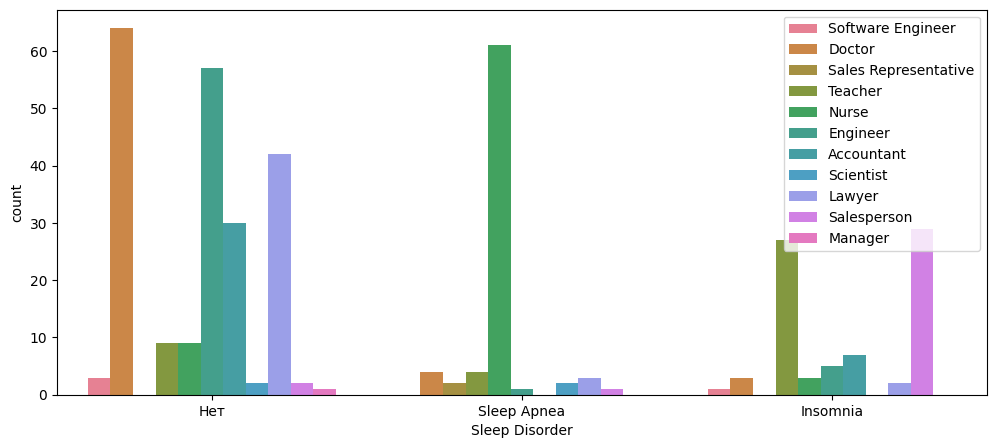

In [10]:
plt.figure(figsize = (12, 5))
sns.countplot(data, x = "Sleep Disorder", hue = "Occupation")
plt.legend(loc = "upper right")
plt.show()

In [11]:
data.describe()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Blood Pressure Sist,Blood Pressure Diast
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,0.494652,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733
std,0.500641,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611
min,0.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000
25%,0.000000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000
50%,0.000000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000
75%,1.000000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000
max,1.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000


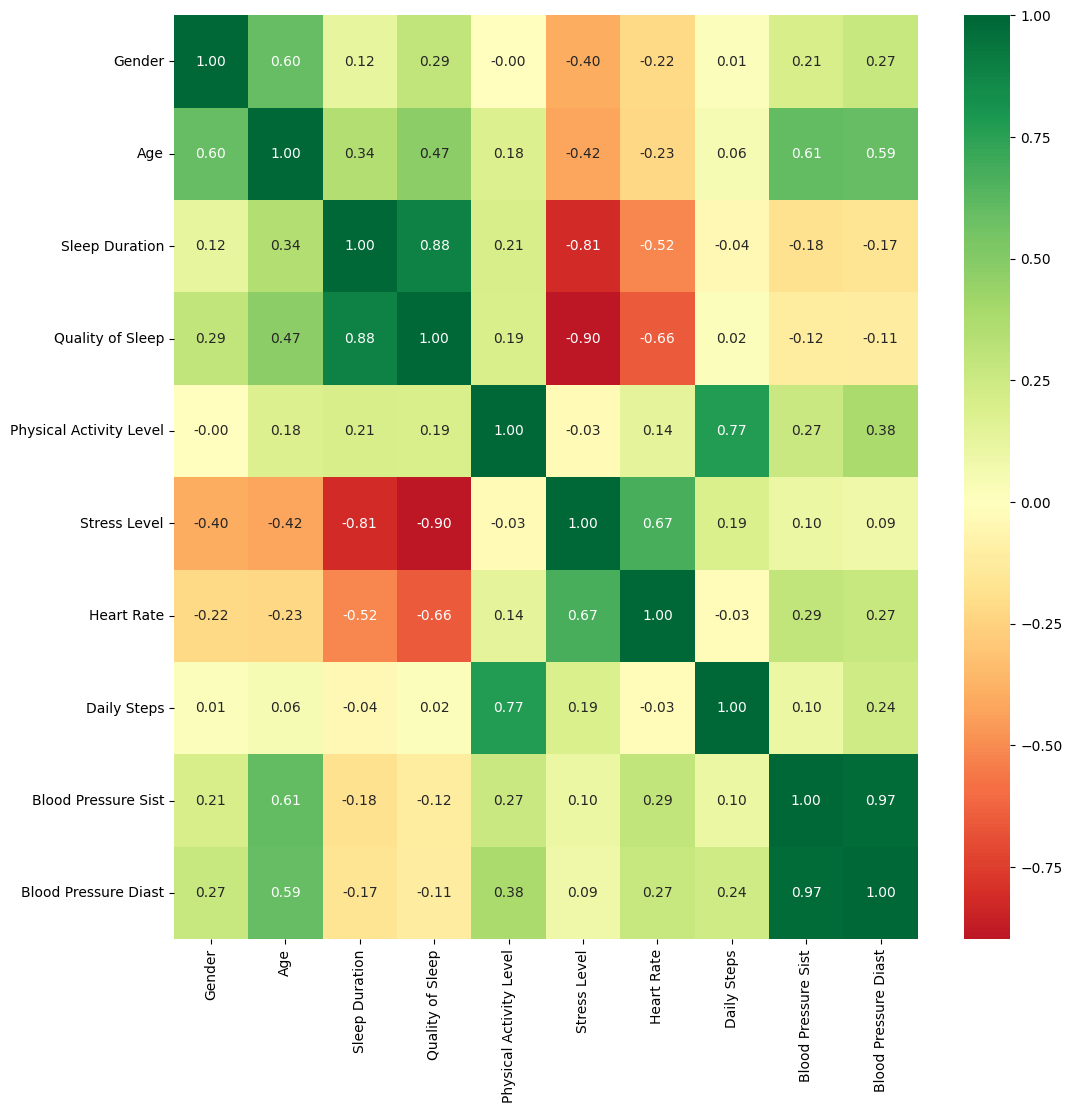

In [12]:
plt.figure(figsize = (12, 12))
sns.heatmap(data.corr(numeric_only = True), 
            annot = True, cmap = "RdYlGn", fmt=".2f", center = 0)
plt.show()

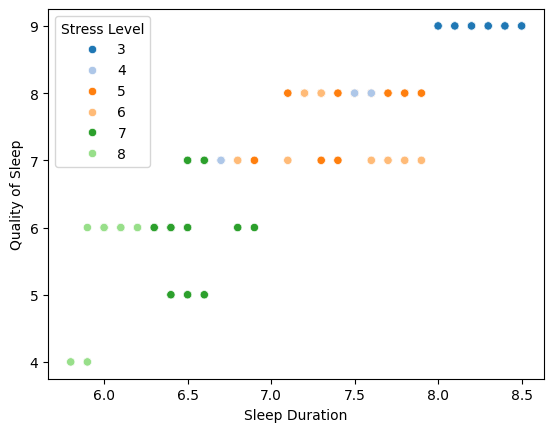

In [13]:
sns.scatterplot(data, x = "Sleep Duration", y = "Quality of Sleep", hue = "Stress Level", palette = "tab20")
plt.show()

In [14]:
data.duplicated(subset=["Quality of Sleep", "Stress Level", "Sleep Duration"]).sum()

np.int64(315)

In [15]:
data["Peace Level"] = data["Sleep Duration"] * data["Quality of Sleep"] / data["Stress Level"]

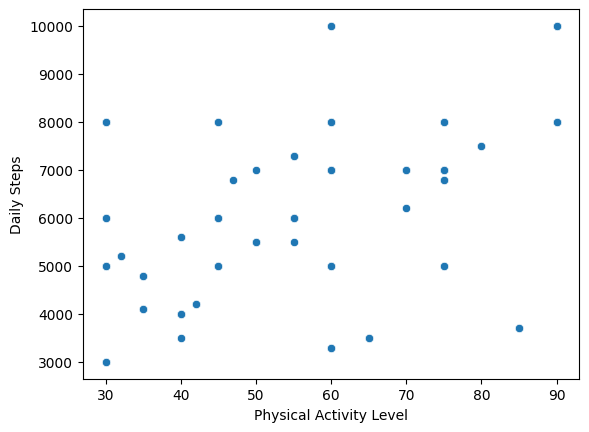

In [16]:
sns.scatterplot(data, x = "Physical Activity Level", y = "Daily Steps")
plt.show()

In [17]:
data.duplicated(subset=["Physical Activity Level", "Daily Steps"]).sum()

np.int64(338)

In [18]:
data["Activity"] = data["Physical Activity Level"] * data["Daily Steps"]

In [19]:
data = data.drop(columns = ["Blood Pressure Diast", "Quality of Sleep", "Stress Level", "Sleep Duration", "Physical Activity Level", "Daily Steps"])

In [20]:
X = data.drop(columns = ["Sleep Disorder"])
y = data[["Sleep Disorder"]]

In [21]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y)

In [22]:
categories = [["Нет", "Insomnia", "Sleep Apnea"]]
oe_sleep = OrdinalEncoder(categories = categories)
y_train = oe_sleep.fit_transform(y_train)
y_test = oe_sleep.transform(y_test)

In [23]:
categories = [["Normal", "Overweight", "Obese"]]
oe_BMI = OrdinalEncoder(categories = categories)
x_train["BMI Category"] = oe_BMI.fit_transform(x_train[["BMI Category"]])
x_test["BMI Category"] = oe_BMI.transform(x_test[["BMI Category"]])

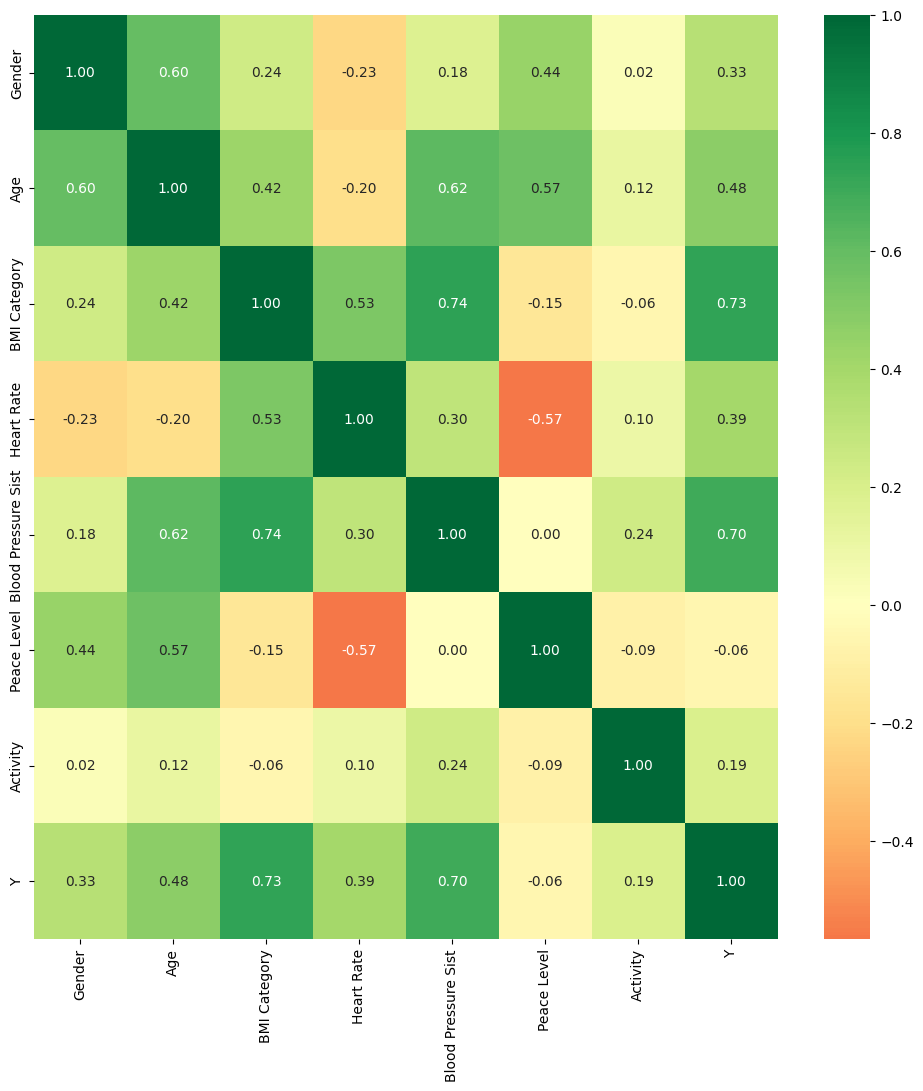

In [24]:
plt.figure(figsize = (12, 12))
sns.heatmap(x_train.join(pd.DataFrame(y_train, index = x_train.index, columns = ["Y"])).corr(numeric_only = True), 
            annot = True, cmap = "RdYlGn", fmt=".2f", center = 0)
plt.show()

In [25]:
ohe_job = OneHotEncoder(sparse_output = False, handle_unknown='ignore', 
                        categories = [list(x_train["Occupation"].value_counts().index[:7])])
occupation = ohe_job.fit_transform(x_train[["Occupation"]])
columns_name = ohe_job.get_feature_names_out()
x_train = x_train.join(pd.DataFrame(occupation, columns = columns_name, index = x_train.index)).drop(columns = "Occupation")
x_test = x_test.join(pd.DataFrame(ohe_job.transform(x_test[["Occupation"]]), columns = columns_name, index = x_test.index)).drop(columns = "Occupation")

In [26]:
y_test = y_test.ravel()
y_train = y_train.ravel()

In [27]:
model_score = pd.DataFrame(np.zeros((7, 4)), 
                           index = ["RidgeClassifier_MinMaxScaler", "RidgeClassifier_StandardScaler", 
                                    "LogisticRegression_MinMaxScaler", "LogisticRegression_StandardScaler",
                                    "KNeighborsClassifier_MinMaxScaler", "KNeighborsClassifier_StandardScaler",
                                    "DecisionTreeClassifier"],
                           columns = ["Train_Macro", "Train_Micro", "Test_Macro", "Test_Micro"])

In [28]:
p1 = Pipeline([("scaler", MinMaxScaler()),
              ("model", RidgeClassifier())])
p2 = Pipeline([("scaler", StandardScaler()),
              ("model", RidgeClassifier())])
p3 = Pipeline([("scaler", MinMaxScaler()),
              ("model", LogisticRegression(max_iter = 1000))])
p4 = Pipeline([("scaler", StandardScaler()),
              ("model", LogisticRegression(max_iter = 1000))])
p5 = Pipeline([("scaler", MinMaxScaler()),
              ("model", KNeighborsClassifier())])
p6 = Pipeline([("scaler", StandardScaler()),
              ("model", KNeighborsClassifier())])

models = [p1, p2, p3, p4, p5, p6, DecisionTreeClassifier()]

for i, p in enumerate(models):
    p.fit(x_train, y_train)
    pred_train = p.predict(x_train)
    pred_test = p.predict(x_test)
    model_score.iloc[i] = [f1_score(y_train, pred_train, average = "macro"), f1_score(y_train, pred_train, average = "micro"),
                                                  f1_score(y_test, pred_test, average = "macro"), f1_score(y_test, pred_test, average = "micro")]


In [29]:
model_score

,Train_Macro,Train_Micro,Test_Macro,Test_Micro
RidgeClassifier_MinMaxScaler,0.888495,0.906355,0.876031,0.906667
RidgeClassifier_StandardScaler,0.899325,0.913043,0.876031,0.906667
LogisticRegression_MinMaxScaler,0.895837,0.913043,0.893727,0.920000
LogisticRegression_StandardScaler,0.906688,0.919732,0.893727,0.920000
KNeighborsClassifier_MinMaxScaler,0.865463,0.889632,0.876031,0.906667
KNeighborsClassifier_StandardScaler,0.879837,0.899666,0.893812,0.920000
DecisionTreeClassifier,0.913596,0.926421,0.898014,0.920000


In [30]:
var = np.concat([np.logspace(-2, 2, 20), [1.0]])

In [31]:
par = {"model__alpha": var}
gs_ridge_mm = GridSearchCV(p1, par, cv = 3, scoring = "f1_macro")
gs_ridge_mm.fit(x_train, y_train)
gs_ridge_mm.best_params_, gs_ridge_mm.best_score_

({'model__alpha': np.float64(0.7847599703514611)},
 np.float64(0.8723022936544412))

In [32]:
par = {"model__alpha": var}
gs_ridge_ss = GridSearchCV(p2, par, cv = 3, scoring = "f1_macro")
gs_ridge_ss.fit(x_train, y_train)
gs_ridge_ss.best_params_, gs_ridge_ss.best_score_

({'model__alpha': np.float64(37.92690190732246)},
 np.float64(0.8784798828730441))

In [33]:
par = {"model__C": var}
gs_logistic_mm = GridSearchCV(p3, par, cv = 3, scoring = "f1_macro")
gs_logistic_mm.fit(x_train, y_train)
gs_logistic_mm.best_params_, gs_logistic_mm.best_score_

({'model__C': np.float64(14.38449888287663)}, np.float64(0.8806430616301467))

In [34]:
par = {"model__C": var}
gs_logistic_ss = GridSearchCV(p4, par, cv = 3, scoring = "f1_macro")
gs_logistic_ss.fit(x_train, y_train)
gs_logistic_ss.best_params_, gs_logistic_ss.best_score_

({'model__C': np.float64(0.7847599703514611)}, np.float64(0.8861792598492717))

In [35]:
par = {"criterion": ["gini", "entropy"],
       "max_depth": [5, 7, 10, 13, 15, None],
       "max_features": ['sqrt', 'log2', 0.5, None],
       "min_samples_leaf": [1, 3, 5, 7, 10, 15],
       "min_samples_split": [2, 5, 10, 15, 20],
       "class_weight": [None, 'balanced'],
       "splitter": ['best', 'random']}

gs_tree = GridSearchCV(DecisionTreeClassifier(), par, cv = 3, scoring = "f1_macro")
gs_tree.fit(x_train, y_train)
gs_tree.best_params_, gs_tree.best_score_

({'class_weight': None,
  'criterion': 'gini',
  'max_depth': 10,
  'max_features': 0.5,
  'min_samples_leaf': 1,
  'min_samples_split': 5,
  'splitter': 'best'},
 np.float64(0.8831154835326718))

In [36]:
par = {"model__n_neighbors": list(range(1, 20)),
      'model__weights': ['uniform', 'distance'],
      'model__p': [1, 2]}
gs_neighbors_mm = GridSearchCV(p5, par, cv = 3, scoring = "f1_macro")
gs_neighbors_mm.fit(x_train, y_train)
gs_neighbors_mm.best_params_, gs_neighbors_mm.best_score_

({'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'distance'},
 np.float64(0.866237232287153))

In [37]:
par = {"model__n_neighbors": list(range(1, 20)),
      'model__weights': ['uniform', 'distance'],
      'model__p': [1, 2]}
gs_neighbors_ss = GridSearchCV(p6, par, cv = 3, scoring = "f1_macro")
gs_neighbors_ss.fit(x_train, y_train)
gs_neighbors_ss.best_params_, gs_neighbors_ss.best_score_

({'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'distance'},
 np.float64(0.866237232287153))

In [38]:
model_score_upgraded = pd.DataFrame(np.zeros((7, 4)), 
                                    index = ["RidgeClassifier_MinMaxScaler", "RidgeClassifier_StandardScaler", 
                                             "LogisticRegression_MinMaxScaler", "LogisticRegression_StandardScaler",
                                             "KNeighborsClassifier_MinMaxScaler", "KNeighborsClassifier_StandardScaler",
                                             "DecisionTreeClassifier"],
                                    columns = ["Train_Macro", "Train_Micro", "Test_Macro", "Test_Micro"])

In [39]:
p7 = Pipeline([("scaler", MinMaxScaler()),
              ("model", RidgeClassifier(alpha = gs_ridge_mm.best_params_["model__alpha"]))])
p8 = Pipeline([("scaler", StandardScaler()),
              ("model", RidgeClassifier(alpha = gs_ridge_ss.best_params_["model__alpha"]))])
p9 = Pipeline([("scaler", MinMaxScaler()),
              ("model", LogisticRegression(max_iter = 1000, C = gs_logistic_mm.best_params_['model__C']))])
p10 = Pipeline([("scaler", StandardScaler()),
              ("model", LogisticRegression(max_iter = 1000, C = gs_logistic_ss.best_params_['model__C']))])
p11 = Pipeline([("scaler", MinMaxScaler()),
              ("model", KNeighborsClassifier(n_neighbors = gs_neighbors_mm.best_params_['model__n_neighbors'], 
                                             weights = gs_neighbors_mm.best_params_['model__weights'], 
                                             p = gs_neighbors_mm.best_params_['model__p']))])
p12 = Pipeline([("scaler", StandardScaler()),
              ("model", KNeighborsClassifier(n_neighbors = gs_neighbors_ss.best_params_['model__n_neighbors'],
                                             weights = gs_neighbors_ss.best_params_['model__weights'], 
                                             p = gs_neighbors_ss.best_params_['model__p']))])

upgraded_models = [p7, p8, p9, p10, p11, p12, DecisionTreeClassifier(**gs_tree.best_params_)]

for i, p in enumerate(upgraded_models):
    p.fit(x_train, y_train)
    pred_train = p.predict(x_train)
    pred_test = p.predict(x_test)
    model_score_upgraded.iloc[i] = [f1_score(y_train, pred_train, average = "macro"), f1_score(y_train, pred_train, average = "micro"),
                                    f1_score(y_test, pred_test, average = "macro"), f1_score(y_test, pred_test, average = "micro")]

In [40]:
model_score

,Train_Macro,Train_Micro,Test_Macro,Test_Micro
RidgeClassifier_MinMaxScaler,0.888495,0.906355,0.876031,0.906667
RidgeClassifier_StandardScaler,0.899325,0.913043,0.876031,0.906667
LogisticRegression_MinMaxScaler,0.895837,0.913043,0.893727,0.920000
LogisticRegression_StandardScaler,0.906688,0.919732,0.893727,0.920000
KNeighborsClassifier_MinMaxScaler,0.865463,0.889632,0.876031,0.906667
KNeighborsClassifier_StandardScaler,0.879837,0.899666,0.893812,0.920000
DecisionTreeClassifier,0.913596,0.926421,0.898014,0.920000


In [41]:
model_score_upgraded

,Train_Macro,Train_Micro,Test_Macro,Test_Micro
RidgeClassifier_MinMaxScaler,0.888495,0.906355,0.876031,0.906667
RidgeClassifier_StandardScaler,0.877553,0.899666,0.876031,0.906667
LogisticRegression_MinMaxScaler,0.906688,0.919732,0.893727,0.920000
LogisticRegression_StandardScaler,0.906688,0.919732,0.893727,0.920000
KNeighborsClassifier_MinMaxScaler,0.913596,0.926421,0.919978,0.946667
KNeighborsClassifier_StandardScaler,0.913596,0.926421,0.919978,0.946667
DecisionTreeClassifier,0.913596,0.926421,0.897403,0.933333
